In [2]:
from winnow_fcns import *
from sim_utils import *
import numpy as np
from pathlib import Path
import os
import csv

In [3]:
class MockBitBuffer:
    def __init__(self, bits):
        self.bits = list(np.array(bits).astype(int))
        self.seed = None
    def get_length(self): return len(self.bits)
    def get_bit(self, i): return self.bits[i]
    def set_bit(self, i): self.bits[i] = 1
    def clear_bit(self, i): self.bits[i] = 0
    def flip_bit(self, i): self.bits[i] = 1 - self.bits[i]
    def set_seed(self, s): self.seed = s
    def permute_buffer(self): pass # Simplified for test

In [4]:

# Get all files (excluding directories)
ch1_file_names_dark = ['4.9/ch1_cyrus4dark.csv','4.9/ch1_cyrus8dark.csv', '4.9/ch1_cyrus32dark.csv']
ch2_file_names_dark = ['4.9/ch2_cyrus4dark.csv', '4.9/ch2_cyrus8dark.csv', '4.9/ch2_cyrus32dark.csv']

ch1_file_names_light = ['4.9/ch1_cyrus4.csv','4.9/ch1_cyrus8.csv', '4.9/ch1_cyrus32.csv']
ch2_file_names_light = ['4.9/ch2_cyrus4.csv', '4.9/ch2_cyrus8.csv', '4.9/ch2_cyrus32.csv']


#------------------files---------------------------------------------
current_file = Path.cwd()

init_file = current_file.parent / "initial_cyrus_bits.csv"
ch1_file = current_file.parent / "ch1_cyrus.csv"
ch2_file = current_file.parent / "ch2_cyrus.csv"



def load_data(init_file, ch1_file, ch2_file):
    init = np.loadtxt(init_file, delimiter=',', dtype=int)
    ch1 = np.loadtxt(ch1_file, delimiter=',')
    ch2 = np.loadtxt(ch2_file, delimiter=',')
    return init, ch1, ch2


init_key, ch1, ch2 = load_data(init_file, ch1_file, ch2_file)





alice_key = MockBitBuffer(list(ch1))
bob_key   = MockBitBuffer(list(ch2))


#  initialize Alice and Bob
alice_winnow = Winnow(raw_key=alice_key, perm_seed=42)
bob_winnow = Winnow(raw_key=bob_key, perm_seed=42)
#use same seed so they dont shuffle keys differently!!!!

# start first pass
alice_winnow.first_pass()
bob_winnow.first_pass()

success_sample = 0
total_sample = 0
with open('corrected/cyrus_test.csv', 'w', newline='') as f:
    # alice calculates syndrome for the first block 
    for i in range(alice_winnow._num_of_blocks):
        alice_syndrome = alice_winnow.get_syndrome(i)
        # bob uses Alice's syndrome to fix his key
        # print(f"Bob's key before fix: {bob_key.bits[:8]}")
        bob_winnow.fix_with_syndrome(i, alice_syndrome)
        # print(f"Bob's key after fix:  {bob_key.bits[:8]}")
        # print(f"Alice's key: {alice_key.bits[:8]}")

        # verify that the keys match
        if i % 100 == 0:
            startb = i*8
            endb = 8 + 8*i
            if alice_key.bits[startb:endb] == bob_key.bits[startb:endb]:
                print(f" Success! Bob corrected the error for block {i}.")
                success_sample+=1
            else:
                print(f"Failure: Keys still do not match for block {i}.")
            total_sample+=1
        
        writer = csv.writer(f)
        for item in bob_key.bits[:8]:
            writer.writerow([item]) # Wrap item in a list

if alice_key.bits == bob_key.bits:
    print(" Success! Bob corrected the error.")
else:
    print("Failure: Keys still do not match.")

print(f"Percentage success {(success_sample/total_sample )* 100} percent")

 Success! Bob corrected the error for block 0.
Failure: Keys still do not match for block 100.
Failure: Keys still do not match for block 200.
Failure: Keys still do not match for block 300.
Failure: Keys still do not match for block 400.
Failure: Keys still do not match for block 500.
Failure: Keys still do not match for block 600.
Failure: Keys still do not match for block 700.
Failure: Keys still do not match for block 800.
Failure: Keys still do not match for block 900.
Failure: Keys still do not match for block 1000.
 Success! Bob corrected the error for block 1100.
 Success! Bob corrected the error for block 1200.
Failure: Keys still do not match for block 1300.
 Success! Bob corrected the error for block 1400.
 Success! Bob corrected the error for block 1500.
Failure: Keys still do not match for block 1600.
Failure: Keys still do not match for block 1700.
Failure: Keys still do not match for block 1800.
Failure: Keys still do not match for block 1900.
 Success! Bob corrected the

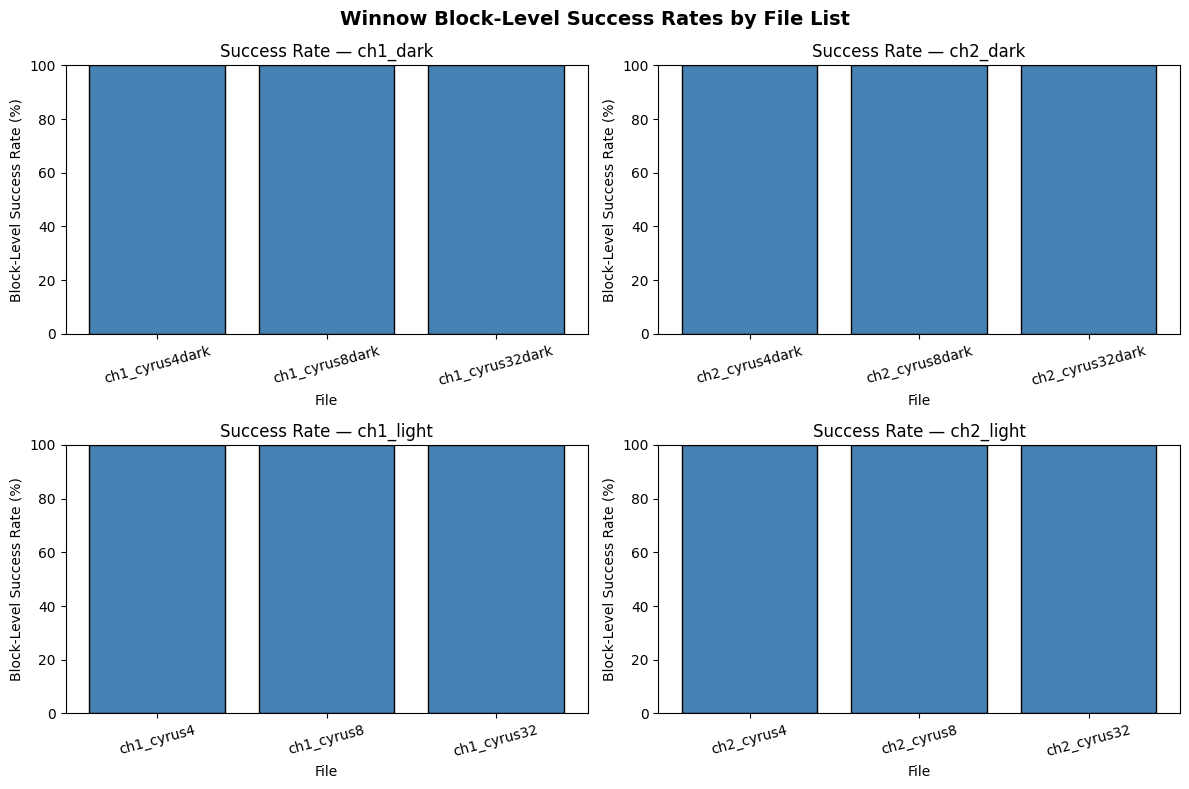

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import csv

#------------------files---------------------------------------------
current_file = Path.cwd()
data_dir = current_file.parent


# Get all files (excluding directories)
ch1_file_names_dark  = [data_dir / '4.9/ch1_cyrus4dark.csv', 
                        data_dir / '4.9/ch1_cyrus8dark.csv', 
                        data_dir / '4.9/ch1_cyrus32dark.csv']

ch2_file_names_dark  = [data_dir / '4.9/ch2_cyrus4dark.csv', 
                        data_dir / '4.9/ch2_cyrus8dark.csv', 
                        data_dir / '4.9/ch2_cyrus32dark.csv']

ch1_file_names_light = [data_dir / '4.9/ch1_cyrus4.csv', 
                        data_dir / '4.9/ch1_cyrus8.csv', 
                        data_dir / '4.9/ch1_cyrus32.csv']

ch2_file_names_light = [data_dir / '4.9/ch2_cyrus4.csv', 
                        data_dir / '4.9/ch2_cyrus8.csv', 
                        data_dir / '4.9/ch2_cyrus32.csv']

# init_file_names = ['init4_cyrus_bits.csv', 'init8_cyrus_bits.csv', 'init32_cyrus_bits.csv']

file_lists = {
    'ch1_dark':  ch1_file_names_dark,
    'ch2_dark':  ch2_file_names_dark,
    'ch1_light': ch1_file_names_light,
    'ch2_light': ch2_file_names_light,
}



# init_file = current_file.parent / "initial_cyrus_bits.csv"


# def load_data(ch1_file, ch2_file):
#     # init = np.loadtxt(init_file, delimiter=',', dtype=int)
#     ch1 = np.loadtxt(ch1_file, delimiter=',')
#     ch2 = np.loadtxt(ch2_file, delimiter=',')
#     return ch1, ch2


def run_winnow(ch1_path, ch2_path):
    """Run Winnow for a given ch1/ch2 file pair and return block-level success rate."""
    ch1_data = np.loadtxt(ch1_path, delimiter=',')
    ch2_data = np.loadtxt(ch2_path, delimiter=',')

    alice_key = MockBitBuffer(list(ch1_data))
    bob_key   = MockBitBuffer(list(ch2_data))

    alice_winnow = Winnow(raw_key=alice_key, perm_seed=42)
    bob_winnow   = Winnow(raw_key=bob_key,   perm_seed=42)

    alice_winnow.first_pass()
    bob_winnow.first_pass()

    success_sample = 0
    total_sample   = 0

    for i in range(alice_winnow._num_of_blocks):
        alice_syndrome = alice_winnow.get_syndrome(i)
        bob_winnow.fix_with_syndrome(i, alice_syndrome)

        if i % 100 == 0:
            startb = i * 8
            endb   = 8 + 8 * i
            if alice_key.bits[startb:endb] == bob_key.bits[startb:endb]:
                success_sample += 1
            total_sample += 1

    return (success_sample / total_sample) * 100 if total_sample > 0 else 0.0


# ---- Pair up ch1 and ch2 files by index within each group ----
# ch1_dark[i] pairs with ch2_dark[i], and ch1_light[i] pairs with ch2_light[i]
paired_lists = {
    'ch1_dark':  (ch1_file_names_dark,  ch2_file_names_dark),
    'ch1_light': (ch1_file_names_light, ch2_file_names_light),
}

# For ch2 lists, swap the pairing perspective if needed, or treat independently.
# Assuming ch1/ch2 files are paired by index across the four lists:
all_groups = {
    'ch1_dark':  list(zip(ch1_file_names_dark,  ch2_file_names_dark)),
    'ch2_dark':  list(zip(ch2_file_names_dark,  ch1_file_names_dark)),
    'ch1_light': list(zip(ch1_file_names_light, ch2_file_names_light)),
    'ch2_light': list(zip(ch2_file_names_light, ch1_file_names_light)),
}

# ---- Collect success rates and plot ----
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (group_name, file_pairs) in zip(axes, all_groups.items()):
    success_rates = []
    labels = []
    print(group_name)

    for ch1_path, ch2_path in file_pairs:
        rate = run_winnow(ch1_path, ch2_path)
        success_rates.append(rate)
        labels.append(Path(ch1_path).stem)  # use filename stem as label

    ax.bar(labels, success_rates, color='steelblue', edgecolor='black')
    ax.set_title(f'Success Rate — {group_name}')
    ax.set_xlabel('File')
    ax.set_ylabel('Block-Level Success Rate (%)')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Winnow Block-Level Success Rates by File List', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('success_rate_histograms.png', dpi=150)
plt.show()